<a href="https://colab.research.google.com/github/marco11235813/Retencion-de-clientes---NoCountry/blob/main/models/ChurnNC_BestModel_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto: Retención de clientes

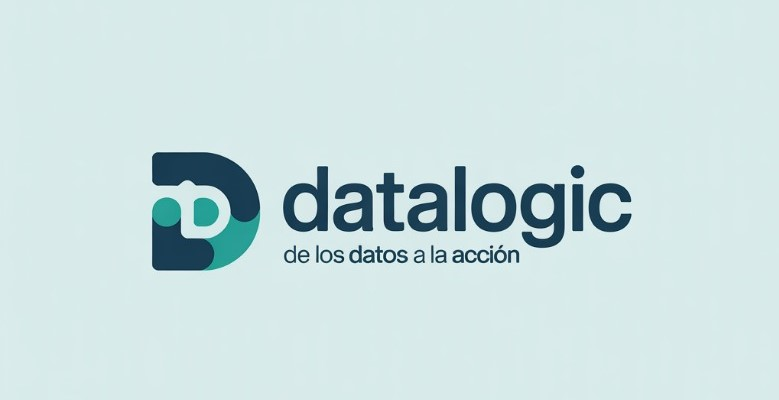

>Este notebook contiene el mejor modelo seleccionado con los parámetros óptimos, con mayor al 93 % de precisión para predecir y distinguir clientes churn (Riesgo de abandono) y no churn (Sin riesgo de abandono).Se encuentra listo para ser vinculado a la app utilizada por la fintech.


##Importación de librerias que serán utilizadas

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
#-------------------------------------------------------------------------------
!pip install scikit-optimize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from skopt import BayesSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
#-------------------------------------------------------------------------------
!pip install transformers
from sklearn.base import BaseEstimator, TransformerMixin
from sentence_transformers import SentenceTransformer
from skopt.space import Real, Categorical, Integer

#Carga y revisión  del dataframe

In [60]:
#Cargo el dataset desde bigQuery
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

from google.cloud import bigquery
client= bigquery.Client(project = 'even-antenna-473123-d3')

query = '''SELECT *
FROM `even-antenna-473123-d3.customer_churn.customer_data`'''
df = client.query(query).to_dataframe()

Authenticated


In [61]:
#Creo un csv con el dataframe
file_path = '/content/customer_tabla.csv'
df.to_csv(file_path, index=False)

#Df_customer
df_customer = pd.read_csv('/content/customer_tabla.csv')

#Modelos

In [62]:
#Definición de target y las features, descarto las columnas que no se utilizarán

#X como features
x= df_customer[['points_in_wallet', 'avg_transaction_value', 'avg_frequency_login_days', 'avg_tx_amount', 'days_since_last_login', 'feedback', 'membership_category']]
#y como target
y= df_customer['churn_risk_score']

In [63]:
#Separo los sets
X_train, X_test, y_train, y_test = train_test_split(x, y, stratify=y, random_state=42, test_size=0.2)

#Print
print('X_train shape:', X_train.shape, '\n',
      'X_test shape:', X_test.shape, '\n',
      'y_train shape:', y_train.shape, '\n',
      'y_test shape:', y_test.shape, '\n')

X_train shape: (25308, 7) 
 X_test shape: (6327, 7) 
 y_train shape: (25308,) 
 y_test shape: (6327,) 



In [64]:
#Columnas a procesar por el modelo
numeric_cols = ['points_in_wallet', 'avg_transaction_value', 'avg_frequency_login_days', 'avg_tx_amount', 'days_since_last_login']
categorical_cols = ['membership_category']
text_col= 'feedback'

In [65]:
#Para tratar el texto
class BertTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        self.model_name = model_name
        self.model = SentenceTransformer(model_name)

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Asegurar que X es iterable de strings
        if hasattr(X, "iloc"):
            X = X.iloc[:,0]
        elif isinstance(X, list):
            X = pd.Series(X)
        X = X.fillna('').astype(str)
        embeddings = self.model.encode(X.tolist(), show_progress_bar=False)
        return embeddings

In [66]:
# Transformer de texto
text_transformer = Pipeline([
    ('bert', BertTransformer())
])

# Transformer numérico y categórico
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Pipeline preprocesamiento
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols),
    ('text', text_transformer, [text_col])
])

In [67]:
#Parámetros XGBOOST
xgboost_params = {
    'n_estimators': 168,
    'max_depth': 4,
    'learning_rate': 0.05,
    'random_state': 42,
    'use_label_encoder': False,
    'eval_metric': 'logloss'
}

#Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(**xgboost_params))
])

#Entrenar al modelo
pipeline.fit(X_train, y_train)

#Predicciones
y_pred = pipeline.predict(X_test)

#Mostrar
print(classification_report(y_test, y_pred),
      accuracy_score(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:59:35] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2893
           1       0.94      0.95      0.94      3434

    accuracy                           0.94      6327
   macro avg       0.94      0.94      0.94      6327
weighted avg       0.94      0.94      0.94      6327
 0.93630472577841


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [68]:
#Joblib XGBoost
joblib.dump(pipeline, 'best_modelML.joblib')

['best_modelML.joblib']

In [70]:

# Instalar librerías necesarias
!pip install gradio joblib numpy pandas xgboost --quiet

# -----------------------
# IMPORTS
# -----------------------
import gradio as gr
import joblib
import numpy as np
import pandas as pd

# -----------------------
# CARGAR MODELO
# -----------------------
# Subir modelo a Colab
modelo = joblib.load('best_modelML.joblib')

def predecir(points_in_wallet, avg_transaction_value, avg_frequency_login_days,
             avg_tx_amount, days_since_last_login, membership_category, feedback):

    try:
        fila_df = pd.DataFrame([{
            'points_in_wallet': float(points_in_wallet),
            'avg_transaction_value': float(avg_transaction_value),
            'avg_frequency_login_days': float(avg_frequency_login_days),
            'avg_tx_amount': float(avg_tx_amount),
            'days_since_last_login': float(days_since_last_login),
            'membership_category': str(membership_category),
            'feedback': str(feedback)
        }])

        pred = modelo.predict(fila_df)[0]

        if pred == 1:
            return "⚠️ Attention: High churn risk identified for this user"
        else:
            return "✅ Status: This user shows no signs of churn risk"

    except Exception as e:
        return f"❌ Error en la predicción: {str(e)}"


# INTERFAZ GRADIO
demo = gr.Interface(
    fn=predecir,
    inputs=[
        gr.Slider(0, 5000, value=100, step=1, label="Points in Wallet"),
        gr.Slider(0, 100000, value=1000, step=10, label="Avg Transaction Value"),
        gr.Slider(0, 200, value=5, step=1, label="Avg Frequency Login Days"),
        gr.Slider(0, 10000, value=300, step=10, label="Avg Tx Amount"),
        gr.Slider(0, 365, value=10, step=1, label="Days Since Last Login"),
        gr.Dropdown(
            label="Membership Category",
            choices=[
                'Platinum Membership',
                'Gold Membership',
                'Silver Membership',
                'Basic Membership',
                'Premium Membership',
                'No Membership'
            ],
            value='Silver Membership'
        ),
        gr.Dropdown(
            label="Feedback Category",
            choices=[
                "Poor product Quality",
                "Neutral experience",
                "No reason specified",
                "Reasonable Price",
                "User Friendly Website",
                "Poor Website",
                "Quality Customer Care",
                "Poor customer service"
            ],
            value="No reason specified"
        )
    ],
    outputs=gr.Textbox(label="Prediction Result"),
    title="🧠 Customer Churn Prediction App",
    description="Adjust the user data with the sliders to predict churn risk using your trained model."
)

# 4️⃣ LANZAR APP
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0cc23bde8585d441c2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
